# Figure 13.

| Author  | Stanley A. Baronett  |
|---------|----------------------|
| Created |  03/04/2026          |
| Updated |  03/04/2026          |

Schematic examples of parallel efficiency.
The dotted green line shows perfect efficiency $\varepsilon_\parallel = 1$ [equation (23)], i.e., speedup $S$ [equation (24)] as a linear function of the number of processing elements $N_
\mathrm{PE}$;
the dashed orange curve theoretical (asymptotic) efficiency, according to Amdahl's law ([G. M. Amdahl 1967](http://doi.org/10.1145/1465482.1465560));
and the solid red curve realistic efficiency, accounting for coordination overhead (Section 3.3.1).
The strictly positive slope of the cyan dashed‒dotted line shows an example measurement of (absolute) $\varepsilon_\parallel$ [equation (25)], e.g., using the serial walltime $T_1$ and the total core-hours $T_{N_\mathrm{pe}}N_\mathrm{pe}$ (Footnote 24) of a parallelized execution.
The negative slope of the olive dashed‒dotted line shows relative efficiency $\varepsilon_\parallel^\mathrm{rel}  < 0$ [equation (27)] beyond a critical $N_\mathrm{pe}$.

/tmp/ipykernel_27707/199472666.py:48: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set(xlabel=r'$N_\mathrm{PE}$', xlim=(0, xmax), xticklabels=['1'], xticks=[0],
/tmp/ipykernel_27707/199472666.py:48: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set(xlabel=r'$N_\mathrm{PE}$', xlim=(0, xmax), xticklabels=['1'], xticks=[0],


[Text(0, 0.5, '$T_1$'), []]

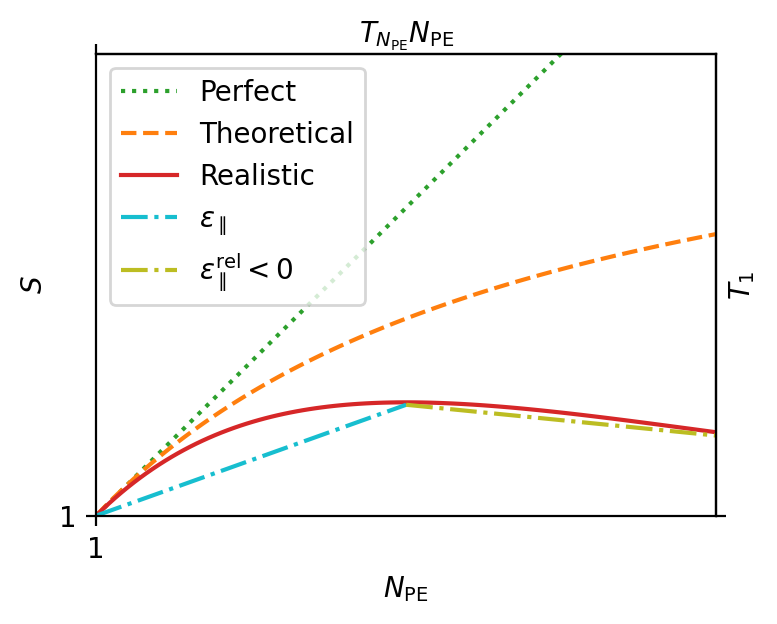

In [1]:
#===============================================================================
import matplotlib.pyplot as plt
import numpy as np

def S(p, f=1/16):
    """
    from Amdahl's law (1967).

     Parameters
    ----------
    p : int
        The number of processing elements.
    f : float
        The fraction of the program that is serial.

    Returns
    -------
    float
        The theoretical speedup of the program.
    """
    return p/(1 + f*(p - 1))

def R(x, a=1.0, b=0.1):
    """
    ...
    """
    return a*x*np.exp(-b*x)

# Plot
xrat, yrat = 4, 3
fig, ax = plt.subplots(figsize=(xrat, yrat), dpi=200)
scale = 5
xmax, ymax = scale*xrat, scale*yrat
p = np.linspace(0, xmax, 100)
ax.plot(p, p, ls='dotted', color='tab:green', label='Perfect')
ax.plot(p, S(p), ls='dashed', color='tab:orange', label='Theoretical')
ax.plot(p, R(p), color='tab:red', label='Realistic')
p_crit, s_crit = 10, 3.6
ax.plot([0, p_crit], [0, s_crit], ls='dashdot', color='tab:cyan',
        label=r'$\varepsilon_\parallel$')
ax.plot([p_crit, 20], [s_crit, 2.6], ls='dashdot', color='tab:olive',
        label=r'$\varepsilon_\parallel^\mathrm{rel} < 0$')

# Format plots
# ax.grid()
ax.legend()
ax.minorticks_on()
ax.set(xlabel=r'$N_\mathrm{PE}$', xlim=(0, xmax), xticklabels=['1'], xticks=[0],
       ylabel=r'$S$', ylim=(0, ymax), yticklabels=['1'], yticks=[0])
ax.tick_params(axis='both', which='both', top=True, right=True)

# Secondary axes
x2 = ax.secondary_xaxis('top')
x2.set(xlabel=r'$T_{N_\mathrm{PE}}N_\mathrm{PE}$', xticks=[])
y2 = ax.secondary_yaxis('right')
y2.set(ylabel=r'$T_1$', yticks=[])